### Machine Learning UberEatsCase EDA (Exploratory Data Analysis)

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
df = pd.read_csv("dataset.csv")

In [12]:
df.describe()

,Driver ID,Restaurant ID,Consumer ID,Order total,Amount of discount,Amount of tip,Refunded amount
count,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000
mean,222.448169,108.721263,32010.313475,51.261496,1.356706,3.492022,0.612091
std,105.219194,98.609766,42010.215766,50.599675,6.516667,3.700115,6.073104
min,7.000000,2.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,141.000000,23.000000,4243.500000,26.660000,0.000000,1.400000,0.000000
50%,227.000000,77.000000,10972.000000,38.630000,0.000000,2.550000,0.000000
75%,314.000000,186.000000,56857.000000,57.885000,0.000000,4.460000,0.000000
max,438.000000,409.000000,200449.000000,1604.130000,187.880000,120.300000,414.770000


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18078 entries, 0 to 18077
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer placed order datetime         18078 non-null  str    
 1   Placed order with restaurant datetime  18038 non-null  str    
 2   Driver at restaurant datetime          13547 non-null  str    
 3   Delivered to consumer datetime         18078 non-null  str    
 4   Driver ID                              18078 non-null  int64  
 5   Restaurant ID                          18078 non-null  int64  
 6   Consumer ID                            18078 non-null  int64  
 7   Delivery Region                        18052 non-null  str    
 8   Is ASAP                                18078 non-null  bool   
 9   Order total                            18078 non-null  float64
 10  Amount of discount                     18078 non-null  float64
 11  Amount of tip

In [14]:
df.isnull().sum()

Customer placed order datetime              0
Placed order with restaurant datetime      40
Driver at restaurant datetime            4531
Delivered to consumer datetime              0
Driver ID                                   0
Restaurant ID                               0
Consumer ID                                 0
Delivery Region                            26
Is ASAP                                     0
Order total                                 0
Amount of discount                          0
Amount of tip                               0
Refunded amount                             0
dtype: int64

In [15]:
"""
Handling Missing Values:
Dapat dilihat dari output dari cell diatas terdapat 3 feature yang memiliki null vaue

1. 'Driver at restaurant datetime' karena terdapat terlalu banyak null value yaitu sebesar
   4531 maka kita tidak menganggap kolom ini relevan dan dapat dibuang
2. Untuk 'Placed order with restaurant datetime' dan 'Delivery Region' kita dapat drop row yang null
"""

# Drop baris yang memiliki null value untuk 'Placed order with restaurant datetime' dan 'Delivery Region'

df.dropna(subset=['Placed order with restaurant datetime', 'Delivery Region'],axis=0,inplace=True)


# Drop kolom Driver at restaurant datetime
df.drop(columns=['Driver at restaurant datetime'], inplace=True)

print(df.isnull().sum())


Customer placed order datetime           0
Placed order with restaurant datetime    0
Delivered to consumer datetime           0
Driver ID                                0
Restaurant ID                            0
Consumer ID                              0
Delivery Region                          0
Is ASAP                                  0
Order total                              0
Amount of discount                       0
Amount of tip                            0
Refunded amount                          0
dtype: int64


Text(0, 0.5, 'Jumlah Pesanan')

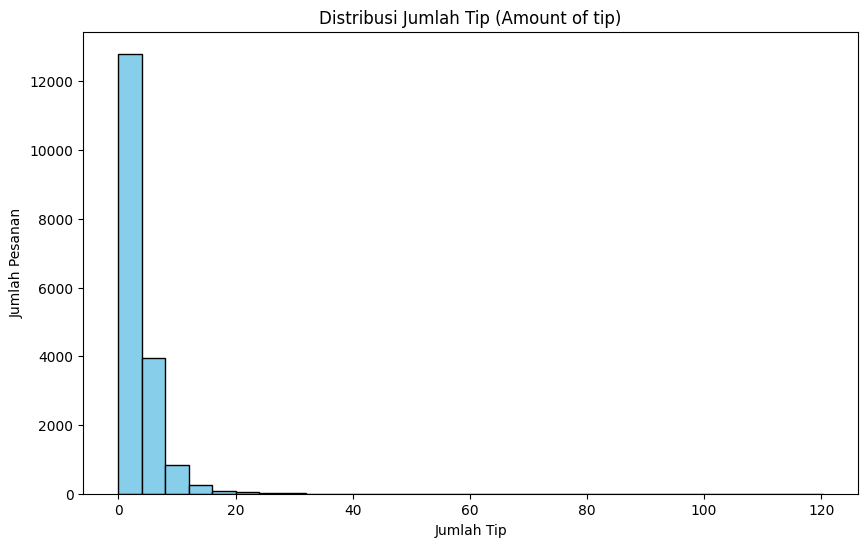

In [16]:
# Visualisasi 

plt.figure(figsize=(10,6))

plt.hist(df['Amount of tip'], bins = 30, color='skyblue', edgecolor='black')
plt.title('Distribusi Jumlah Tip (Amount of tip)')
plt.xlabel('Jumlah Tip')
plt.ylabel('Jumlah Pesanan')

### Catatan
**Driver at restaurant datetime** -> drop coloumn, karena tidak penting  
**Delivery Region ama Customer placed order datetime** => drop row

### Tujuan Analisis
1. **Prediksi Amount Of Tip (Y), Order Total(X), Delivery Region(X), (Driver to consumer datetime - Customer placed order datetime)(X)**
2. Customer placed order time (Y),  Delivery Region(X)
3. Order Total harganya(Y), diskon(X) 
